# Выявление профилей потребления покупателей интернет-магазина

**Цель проекта:** сегментировать покупателей интернет-магазина товаров для дома «Пока все ещё тут» по покупательскому поведению и подготовить рекомендации для маркетинга.

В этой версии ноутбук переписан так, чтобы его было проще проверять и воспроизводить: локальные пути заменены на относительные, повторяющаяся логика вынесена в функции, очистка данных стала прозрачнее, а итоговые таблицы сохраняются как отдельные артефакты.

## План анализа

1. Загрузить и проверить данные.
2. Очистить транзакции от дублей, конфликтующих заказов и явных аномалий.
3. Категоризировать товары и проверить, что вся выручка попадает в категории.
4. Проанализировать выручку, заказы, средний чек и сезонность.
5. Провести RFM-сегментацию покупателей.
6. Проверить статистические различия между сегментами.
7. Сформулировать рекомендации для маркетинга.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from itertools import combinations
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH = Path('data/ecommerce_dataset.csv')
OUTPUT_DIR = Path('outputs/notebook_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_FORMAT = '%Y%m%d%H'
REQUIRED_COLUMNS = ['date', 'customer_id', 'order_id', 'product', 'quantity', 'price']
SEGMENT_ORDER = ['лояльные', 'новые', 'потенциальные', 'спящие']
RANDOM_STATE = 42

plt.style.use('seaborn-v0_8-whitegrid')

## Служебные функции

Ниже собраны функции для загрузки, очистки, категоризации, сегментации и статистических тестов. Такой формат делает ноутбук короче и снижает риск ошибок при повторном запуске отдельных ячеек.

In [2]:
@dataclass(frozen=True)
class CleaningReport:
    raw_rows: int
    rows_after_type_validation: int
    removed_duplicate_item_rows: int
    removed_customer_conflict_rows: int
    removed_date_conflict_rows: int
    removed_extreme_quantity_rows: int
    final_rows: int
    final_orders: int
    final_customers: int
    date_min: str
    date_max: str


def normalize_text(value: Any) -> str:
    if pd.isna(value):
        return ''
    return ' '.join(str(value).lower().replace('ё', 'е').split())


def validate_columns(df: pd.DataFrame) -> None:
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f'В датасете не хватает колонок: {missing_columns}')


def load_transactions(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f'Файл {path} не найден. Скачайте ecommerce_dataset.csv и положите его в папку data/.'
        )

    df = pd.read_csv(path)
    validate_columns(df)

    df = df[REQUIRED_COLUMNS].copy()
    df['date'] = pd.to_datetime(df['date'].astype(str), format=DATE_FORMAT, errors='coerce')
    df['customer_id'] = df['customer_id'].astype(str).str.strip()
    df['order_id'] = pd.to_numeric(df['order_id'], errors='coerce').astype('Int64')
    df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['product_original'] = df['product'].astype(str)
    df['product'] = df['product'].map(normalize_text)

    df = df.dropna(subset=['date', 'order_id', 'quantity', 'price'])
    df = df[(df['quantity'] > 0) & (df['price'] > 0)]
    df['order_id'] = df['order_id'].astype(int)
    df['quantity'] = df['quantity'].astype(int)

    return df.reset_index(drop=True)

### Категоризация товаров

Правила категорий сохранены из исходного проекта, но добавлена важная правка: товары, которые не попали ни в одну категорию, теперь явно маркируются как `другое`. Так выручка по категориям сходится с общей выручкой.

In [3]:
CATEGORY_KEYWORDS = {'посуда и аксессуары': ('кружка',
                         'банка',
                         'бидон',
                         'блюдце',
                         'бульонница',
                         'ваза',
                         'венчик',
                         'вилка',
                         'раздел',
                         'емкость',
                         'измельч',
                         'картофелемялка',
                         'кастрюля',
                         'кипятильник',
                         'кисточка',
                         'ковш',
                         'контейнер',
                         'котел',
                         'круж',
                         'крышка',
                         'кувшин',
                         'кухон',
                         'ложка',
                         'лопатка',
                         'лоток',
                         'мантовар',
                         'маслен',
                         'стакан',
                         'миксер',
                         'сковорода',
                         'миска',
                         'модульная',
                         'муляж',
                         'бокал',
                         'нож',
                         'посуд',
                         'столов',
                         'набор форм',
                         'фужер',
                         'эмалирован',
                         'овоще',
                         'орехоколка',
                         'отделитель',
                         'отжим',
                         'половник',
                         'просеиватель',
                         'противень',
                         'разделочная',
                         'рыбочистка',
                         'салатник',
                         'сахарница',
                         'сито',
                         'скалка',
                         'скребок',
                         'соковарка',
                         'соковыжималка',
                         'сотейник',
                         'тарелка',
                         'терка',
                         'термокружка',
                         'термос',
                         'толкушка',
                         'тортница',
                         'хлебница',
                         'чайн',
                         'шприц',
                         'электроштопор'),
 'цветы и растения': ('рассада',
                      'адиантум',
                      'азалия',
                      'аквилегия',
                      'алиссум',
                      'алоэ',
                      'альбука',
                      'амариллис',
                      'анемона',
                      'антуриум',
                      'аптения',
                      'арбуз',
                      'артемизия',
                      'аспарагус',
                      'астра',
                      'афеляндра',
                      'бадан',
                      'базилик',
                      'баклажан',
                      'бакопа',
                      'бальзамин',
                      'барвинок',
                      'бархатцы',
                      'бегония',
                      'буддлея',
                      'бузульник',
                      'валериана',
                      'верб',
                      'вероника',
                      'вигна',
                      'виола',
                      'газания',
                      'гайлардия',
                      'гардения',
                      'гвоздика',
                      'георгина',
                      'гер',
                      'гиацинт',
                      'гимнокал',
                      'гиностемма',
                      'гипсофила',
                      'глоксиния',
                      'годеция',
                      'гор',
                      'виноград',
                      'декабрист',
                      'дендробиум',
                      'джункус',
                      'диффенбахия',
                      'драцена',
                      'душица',
                      'дыня',
                      'ель',
                      'замиок',
                      'зверобой',
                      'землян',
                      'змеегол',
                      'импат',
                      'иссоп',
                      'кабачок',
                      'кала',
                      'календ',
                      'калибрах',
                      'калл',
                      'калоцеф',
                      'кампанула',
                      'капсикум',
                      'капуста',
                      'кипарисовик',
                      'клен',
                      'клубника',
                      'кодонанта',
                      'колокольчик',
                      'растение',
                      'кореопсис',
                      'кориандр',
                      'космея',
                      'котовник',
                      'кофе',
                      'крассула',
                      'крокусы',
                      'лаванда',
                      'лаватера',
                      'лавр',
                      'лантана',
                      'лапчатка',
                      'лен',
                      'лилейник',
                      'литопс',
                      'лобелия',
                      'лук',
                      'зев',
                      'любисток',
                      'маттиола',
                      'мединил',
                      'мелисса',
                      'мимоза',
                      'мирт',
                      'молодило',
                      'монарда',
                      'морковь',
                      'муррайя',
                      'мускари',
                      'мята',
                      'настурция',
                      'незабудка',
                      'нефролепис',
                      'ромашка',
                      'нолина',
                      'овсянница',
                      'огурец',
                      'осина',
                      'папорот',
                      'патиссон',
                      'пахира',
                      'пеларгония',
                      'пеперомия',
                      'петрушка',
                      'петуния',
                      'пиретрум',
                      'платикодон махровый',
                      'подар',
                      'подсолнечник',
                      'примула',
                      'травы',
                      'пуансет',
                      'радермахера',
                      'ранункулус',
                      'роза',
                      'розмарин',
                      'рудбекия',
                      'салат рукола',
                      'сантолина',
                      'седум',
                      'сельдерей',
                      'синнингия',
                      'скиммия',
                      'смолевка',
                      'соланум',
                      'солидаго',
                      'спатифиллум',
                      'суккулент',
                      'сциндапсус',
                      'табак',
                      'тагетис',
                      'тимьян',
                      'томат',
                      'тыква',
                      'тюльпан',
                      'укроп',
                      'фаленопсис',
                      'фатсия',
                      'фиалка',
                      'физостегия',
                      'фикус',
                      'фиттония',
                      'флокс',
                      'фуксия',
                      'хлорофитум',
                      'хоста',
                      'хриз',
                      'комнатное',
                      'целозия',
                      'цикламен',
                      'цинерания',
                      'цинния',
                      'циперус',
                      'цитрофортунелла',
                      'хамедорея',
                      'чабер',
                      'шалфей',
                      'шеффлера',
                      'эвкалипт',
                      'энотера',
                      'эпипремнум',
                      'эхеверия',
                      'эхин',
                      'эшшольция',
                      'юкка',
                      'ясколка'),
 'хранение, сумки и тележки': ('комод',
                               'корзин',
                               'стеллаж',
                               'короб',
                               'кофр',
                               'обувница',
                               'полк',
                               'складная картонная',
                               'сумка',
                               'тележка',
                               'этажерка',
                               'ящик для',
                               'сумка-тележка 2-х'),
 'товары для дома': ('антижир',
                     'антинакипин',
                     'ароматизир',
                     'бальзам для',
                     'прищеп',
                     'пакет',
                     'ванна',
                     'вантуз',
                     'ведро',
                     'веник',
                     'весы',
                     'вешал',
                     'гипоаллерг',
                     'гладил',
                     'губка',
                     'скатерть',
                     'постель',
                     'декорат',
                     'держатель',
                     'дозатор',
                     'ерш',
                     'мыл',
                     'соль',
                     'паста',
                     'искусст',
                     'ключница',
                     'ковер',
                     'ковр',
                     'ковёр',
                     'кольца',
                     'комплект для',
                     'махр',
                     'постель',
                     'кондиционер',
                     'концентрат',
                     'корыто',
                     'крючок',
                     'лестница',
                     'мешок',
                     'vileda',
                     'набор для',
                     'наволочка',
                     'наматра',
                     'насадк',
                     'сушил',
                     'салфет',
                     'новогоднее дерево',
                     'одеяло',
                     'окномойка',
                     'ополаскиватель',
                     'основание',
                     'отбеливатель',
                     'паста',
                     'перчатки',
                     'плед',
                     'плечики',
                     'кашпо',
                     'подголовник',
                     'подкладка',
                     'пододеяльник',
                     'подрукавник',
                     'подставка',
                     'подушка',
                     'покрывало',
                     'покрытие',
                     'пресс',
                     'пробка',
                     'простын',
                     'пылесос',
                     'пьезозажигалка',
                     'рассекатель',
                     'ролик',
                     'рукав',
                     'светильник',
                     'сетка для',
                     'сиденье',
                     'складной детский',
                     'сменная насадка',
                     'сменный блок',
                     'сметка',
                     'совок',
                     'средство',
                     'биопорошок',
                     'стремянка',
                     'сушилка',
                     'таз',
                     'термометр',
                     'ткань',
                     'тряпк',
                     'утюг',
                     'фен',
                     'чехол',
                     'швабра',
                     'штора',
                     'щетка',
                     'халат',
                     'ящик почтовый'),
 'строительные товары': ('бензин',
                         'вкладыши',
                         'завертка',
                         'насадка',
                         'экран',
                         'измерит',
                         'камнеломка',
                         'карниз',
                         'крепеж',
                         'линейка',
                         'инструмент',
                         'прецизионных',
                         'набор сверел',
                         'пена',
                         'петля',
                         'пружина',
                         'вентиляционная',
                         'ручк',
                         'сверл',
                         'стяжк',
                         'уголок',
                         'капроновый',
                         'хром',
                         'холодная сварка',
                         'шило',
                         'шнур',
                         'шпагат',
                         'шпингалет',
                         'штанг')}


def categorize_product(product: str) -> str:
    product = normalize_text(product)
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(keyword in product for keyword in keywords):
            return category
    return 'другое'


In [4]:
def remove_duplicate_order_items(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    before = len(df)
    cleaned = (
        df.sort_values(['customer_id', 'order_id', 'product', 'date'])
        .drop_duplicates(subset=['customer_id', 'order_id', 'product'], keep='first')
        .reset_index(drop=True)
    )
    return cleaned, before - len(cleaned)


def remove_conflicting_orders(df: pd.DataFrame, column: str) -> tuple[pd.DataFrame, int]:
    conflicting_order_ids = (
        df.groupby('order_id')[column]
        .nunique()
        .loc[lambda counts: counts > 1]
        .index
    )
    before = len(df)
    cleaned = df[~df['order_id'].isin(conflicting_order_ids)].copy()
    return cleaned.reset_index(drop=True), before - len(cleaned)


def remove_extreme_quantity_rows(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    # В исходном проекте была найдена одна явная аномалия: заказ на 1000 единиц товара.
    extreme_mask = df['quantity'] >= 1000
    before = len(df)
    cleaned = df[~extreme_mask].copy()
    return cleaned.reset_index(drop=True), before - len(cleaned)


def clean_transactions(df: pd.DataFrame) -> tuple[pd.DataFrame, CleaningReport]:
    raw_rows = len(df)

    df = df.dropna(subset=REQUIRED_COLUMNS).reset_index(drop=True)
    rows_after_type_validation = len(df)

    df, removed_duplicate_item_rows = remove_duplicate_order_items(df)
    df, removed_customer_conflict_rows = remove_conflicting_orders(df, 'customer_id')
    df, removed_date_conflict_rows = remove_conflicting_orders(df, 'date')
    df, removed_extreme_quantity_rows = remove_extreme_quantity_rows(df)

    if df.empty:
        raise ValueError('После очистки не осталось строк. Проверьте данные и правила очистки.')

    df = df.copy()
    df['product_short'] = df['product'].str.split().str[:2].str.join(' ')
    df['category'] = df['product_short'].map(categorize_product)
    df['total_amount'] = df['quantity'] * df['price']

    report = CleaningReport(
        raw_rows=raw_rows,
        rows_after_type_validation=rows_after_type_validation,
        removed_duplicate_item_rows=removed_duplicate_item_rows,
        removed_customer_conflict_rows=removed_customer_conflict_rows,
        removed_date_conflict_rows=removed_date_conflict_rows,
        removed_extreme_quantity_rows=removed_extreme_quantity_rows,
        final_rows=len(df),
        final_orders=df['order_id'].nunique(),
        final_customers=df['customer_id'].nunique(),
        date_min=df['date'].min().strftime('%Y-%m-%d %H:%M:%S'),
        date_max=df['date'].max().strftime('%Y-%m-%d %H:%M:%S'),
    )
    return df.reset_index(drop=True), report

In [5]:
def build_category_summary(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby('category', as_index=False)
        .agg(
            revenue=('total_amount', 'sum'),
            items=('quantity', 'sum'),
            orders=('order_id', 'nunique'),
            products=('product_short', 'nunique'),
        )
        .assign(avg_order_value=lambda x: x['revenue'] / x['orders'])
        .sort_values('revenue', ascending=False)
        .reset_index(drop=True)
        .round({'revenue': 2, 'avg_order_value': 2})
    )


def build_monthly_summary(df: pd.DataFrame) -> pd.DataFrame:
    monthly = df.copy()
    monthly['month'] = monthly['date'].dt.to_period('M').astype(str)
    return (
        monthly.groupby(['month', 'category'], as_index=False)
        .agg(
            revenue=('total_amount', 'sum'),
            orders=('order_id', 'nunique'),
            items=('quantity', 'sum'),
        )
        .assign(avg_order_value=lambda x: x['revenue'] / x['orders'])
        .sort_values(['month', 'revenue'], ascending=[True, False])
        .reset_index(drop=True)
        .round({'revenue': 2, 'avg_order_value': 2})
    )


def build_rfm_table(df: pd.DataFrame) -> pd.DataFrame:
    anchor_date = df['date'].max().normalize() + pd.Timedelta(days=1)
    rfm = (
        df.groupby('customer_id', as_index=False)
        .agg(
            last_order_date=('date', 'max'),
            frequency=('order_id', 'nunique'),
            total_revenue=('total_amount', 'sum'),
        )
        .assign(
            recency=lambda x: (anchor_date - x['last_order_date']).dt.days.astype(int),
            monetary_value=lambda x: x['total_revenue'] / x['frequency'],
        )
    )

    recency_q1 = rfm['recency'].quantile(0.25)
    recency_q2 = rfm['recency'].quantile(0.50)
    monetary_q1 = rfm['monetary_value'].quantile(0.25)
    monetary_q2 = rfm['monetary_value'].quantile(0.50)

    rfm['r_score'] = np.select(
        [rfm['recency'] <= recency_q1, rfm['recency'] <= recency_q2],
        [3, 2],
        default=1,
    )
    rfm['f_score'] = np.where(rfm['frequency'] > 1, 2, 1)
    rfm['m_score'] = np.select(
        [rfm['monetary_value'] <= monetary_q1, rfm['monetary_value'] <= monetary_q2],
        [1, 2],
        default=3,
    )
    rfm['rfm_code'] = (
        rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
    )
    rfm['customer_segment'] = rfm.apply(assign_customer_segment, axis=1)
    return rfm.sort_values(['customer_segment', 'monetary_value'], ascending=[True, False])


def assign_customer_segment(row: pd.Series) -> str:
    if row['r_score'] == 3 and row['f_score'] == 2 and row['m_score'] >= 2:
        return 'лояльные'
    if row['r_score'] == 3:
        return 'новые'
    if row['r_score'] == 2:
        return 'потенциальные'
    return 'спящие'


def attach_segments(df: pd.DataFrame, rfm: pd.DataFrame) -> pd.DataFrame:
    return df.merge(
        rfm[['customer_id', 'customer_segment', 'rfm_code']],
        on='customer_id',
        how='left',
    )

In [6]:
def build_segment_summary(df: pd.DataFrame, rfm: pd.DataFrame) -> pd.DataFrame:
    transaction_metrics = (
        df.groupby('customer_segment', as_index=False, observed=True)
        .agg(revenue=('total_amount', 'sum'), orders=('order_id', 'nunique'), items=('quantity', 'sum'))
    )
    customer_metrics = (
        rfm.groupby('customer_segment', as_index=False, observed=True)
        .agg(
            customers=('customer_id', 'nunique'),
            avg_recency_days=('recency', 'mean'),
            avg_frequency=('frequency', 'mean'),
            avg_customer_check=('monetary_value', 'mean'),
        )
    )
    summary = transaction_metrics.merge(customer_metrics, on='customer_segment', how='outer')
    summary['avg_order_value'] = summary['revenue'] / summary['orders']
    summary['orders_per_customer'] = summary['orders'] / summary['customers']
    summary['customer_segment'] = pd.Categorical(
        summary['customer_segment'], categories=SEGMENT_ORDER, ordered=True
    )
    return (
        summary.sort_values('customer_segment')
        .reset_index(drop=True)
        .round({
            'revenue': 2,
            'avg_recency_days': 1,
            'avg_frequency': 2,
            'avg_customer_check': 2,
            'avg_order_value': 2,
            'orders_per_customer': 2,
        })
    )


def build_segment_category_summary(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(['customer_segment', 'category'], as_index=False, observed=True)
        .agg(revenue=('total_amount', 'sum'), orders=('order_id', 'nunique'), items=('quantity', 'sum'))
        .sort_values(['customer_segment', 'revenue'], ascending=[True, False])
        .reset_index(drop=True)
        .round({'revenue': 2})
    )


def holm_adjust_p_values(p_values: pd.Series | np.ndarray) -> np.ndarray:
    p_values_array = np.asarray(p_values, dtype=float)
    n_values = len(p_values_array)
    if n_values == 0:
        return np.array([])
    order = np.argsort(p_values_array)
    sorted_p_values = p_values_array[order]
    multipliers = n_values - np.arange(n_values)
    adjusted_sorted = np.maximum.accumulate(sorted_p_values * multipliers)
    adjusted_sorted = np.clip(adjusted_sorted, 0, 1)
    adjusted = np.empty(n_values, dtype=float)
    adjusted[order] = adjusted_sorted
    return adjusted


def compare_segments(rfm: pd.DataFrame, metric: str, alpha: float = 0.05) -> pd.DataFrame:
    groups = {
        segment: values[metric].dropna()
        for segment, values in rfm.groupby('customer_segment', observed=True)
        if len(values[metric].dropna()) > 0
    }
    results = []
    for segment_a, segment_b in combinations(groups, 2):
        statistic, p_value = stats.mannwhitneyu(
            groups[segment_a], groups[segment_b], alternative='two-sided'
        )
        results.append({
            'metric': metric,
            'segment_a': segment_a,
            'segment_b': segment_b,
            'statistic': statistic,
            'p_value': p_value,
        })
    result_df = pd.DataFrame(results)
    if result_df.empty:
        return result_df
    result_df['adjusted_p_value'] = holm_adjust_p_values(result_df['p_value'])
    result_df['reject_h0'] = result_df['adjusted_p_value'] < alpha
    result_df['conclusion'] = np.where(
        result_df['reject_h0'],
        'есть статистически значимая разница',
        'статистически значимой разницы не обнаружено',
    )
    return result_df.sort_values(['metric', 'adjusted_p_value']).reset_index(drop=True)

In [7]:
def barh_table_plot(df: pd.DataFrame, x: str, y: str, title: str, xlabel: str) -> None:
    plot_df = df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(plot_df[y], plot_df[x], color='#4472C4')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    for index, value in enumerate(plot_df[x]):
        ax.text(value, index, f' {value:,.0f}', va='center')
    plt.tight_layout()
    plt.show()


def line_plot(df: pd.DataFrame, value: str, title: str, ylabel: str) -> None:
    pivot = df.pivot_table(index='month', columns='category', values=value, aggfunc='sum').fillna(0)
    ax = pivot.plot(figsize=(13, 6), marker='o')
    ax.set_title(title)
    ax.set_xlabel('Месяц')
    ax.set_ylabel(ylabel)
    ax.legend(title='Категория', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 1. Загрузка и первичная проверка данных

In [8]:
raw_data = load_transactions(DATA_PATH)

print(f'Строк: {len(raw_data):,}')
print(f'Покупателей: {raw_data["customer_id"].nunique():,}')
print(f'Заказов: {raw_data["order_id"].nunique():,}')
print(f'Период: {raw_data["date"].min()} — {raw_data["date"].max()}')

display(raw_data.head())
display(raw_data[REQUIRED_COLUMNS].isna().sum().to_frame('missing_values'))

Строк: 6,737
Покупателей: 2,451
Заказов: 2,784
Период: 2018-10-01 00:00:00 — 2019-10-31 16:00:00


,date,customer_id,order_id,product,quantity,price,product_original
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.00,"Комнатное растение в горшке Алое Вера, d12, h30"
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.00,"Комнатное растение в горшке Кофе Арабика, d12,..."
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.00,Радермахера d-12 см h-20 см
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.00,Хризолидокарпус Лутесценс d-9 см
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.00,Циперус Зумула d-12 см h-25 см


,missing_values
date,0
customer_id,0
order_id,0
product,0
quantity,0
price,0


**Промежуточный вывод:** пропуски в ключевых колонках отсутствуют, даты приведены к типу `datetime`, названия товаров нормализованы к нижнему регистру. Данные покрывают период чуть больше года, поэтому сезонные эффекты можно анализировать, но выводы о сезонности стоит считать предварительными.

## 2. Очистка данных

В исходном ноутбуке крупная часть строк удалялась как неявные дубликаты. Здесь очистка вынесена в отдельный отчёт, чтобы было видно, какие именно записи исключены.

In [9]:
transactions, cleaning_report = clean_transactions(raw_data)
cleaning_report_df = pd.DataFrame([asdict(cleaning_report)])

display(cleaning_report_df.T.rename(columns={0: 'value'}))
print(f'Общая выручка после очистки: {transactions["total_amount"].sum():,.0f}')

display(transactions.head())

,value
raw_rows,6737
rows_after_type_validation,6737
removed_duplicate_item_rows,1886
removed_customer_conflict_rows,66
removed_date_conflict_rows,50
removed_extreme_quantity_rows,1
final_rows,4734
final_orders,2742
final_customers,2383
date_min,2018-10-01 00:00:00


Общая выручка после очистки: 3,385,607


,date,customer_id,order_id,product,quantity,price,product_original,product_short,category,total_amount
0,2019-10-16 08:00:00,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,пеларгония зональная диам. 12 см темнорозовая ...,1,150.00,Пеларгония зональная диам. 12 см темнорозовая ...,пеларгония зональная,цветы и растения,150.00
1,2019-10-16 08:00:00,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,пеларгония розебудная queen ingrid укорененный...,1,135.00,Пеларгония розебудная Queen Ingrid укорененный...,пеларгония розебудная,цветы и растения,135.00
2,2019-10-16 08:00:00,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,пеларгония розебудная rosebud red d-7 см,1,135.00,Пеларгония розебудная Rosebud Red d-7 см,пеларгония розебудная,цветы и растения,135.00
3,2019-10-16 08:00:00,000d6849-084e-4d9f-ac03-37174eaf60c4,14943,пеларгония тюльпановидная emma,1,135.00,Пеларгония тюльпановидная EMMA,пеларгония тюльпановидная,цветы и растения,135.00
4,2019-02-16 11:00:00,001cee7f-0b29-4716-b202-0042213ab038,70290,сушилка для белья потолочная лиана люкс 150 см...,1,442.00,Сушилка для белья потолочная ЛИАНА ЛЮКС 150 см...,сушилка для,товары для дома,442.00


**Промежуточный вывод:** после очистки остались согласованные транзакции без повторов на уровне `customer_id + order_id + product`. Экстремальный заказ на 1000 единиц исключён как выброс, способный исказить выручку, количество товаров и средний чек.

## 3. Категории товаров и выручка

,category,revenue,items,orders,products,avg_order_value
0,товары для дома,"1,510,644.00",4409,1161,237,"1,301.16"
1,"хранение, сумки и тележки","830,289.00",524,419,34,"1,981.60"
2,цветы и растения,"552,168.00",3691,751,411,735.24
3,посуда и аксессуары,"367,886.00",2645,377,190,975.82
4,другое,"62,523.00",25,19,10,"3,290.68"
5,строительные товары,"62,097.00",1082,67,36,926.82


Проверка суммы выручки по категориям: разница = 0.00


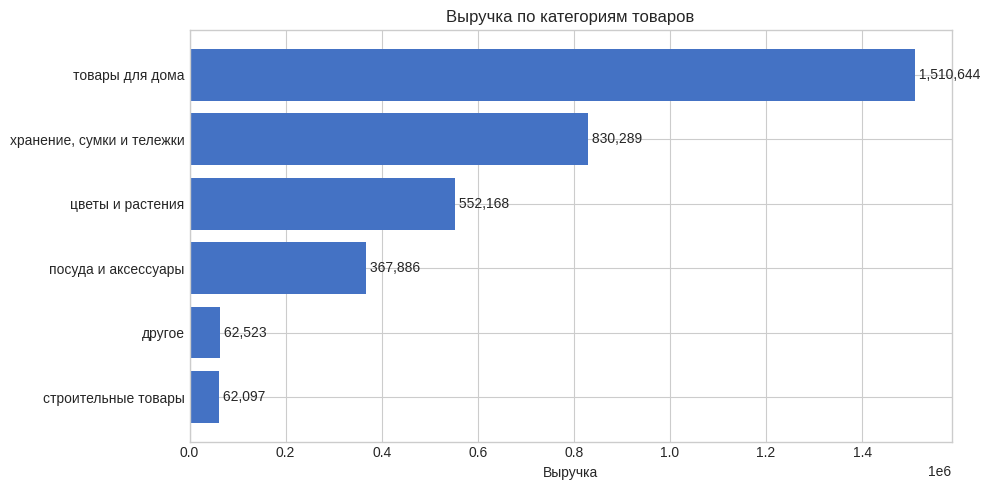

In [10]:
category_summary = build_category_summary(transactions)
display(category_summary)

revenue_check = category_summary['revenue'].sum() - transactions['total_amount'].sum()
print(f'Проверка суммы выручки по категориям: разница = {revenue_check:,.2f}')

barh_table_plot(
    category_summary,
    x='revenue',
    y='category',
    title='Выручка по категориям товаров',
    xlabel='Выручка',
)

**Промежуточный вывод:** наибольшую выручку дают товары для дома, затем товары для хранения и перемещения. Категория `другое` добавлена намеренно: она показывает товары, которые требуют уточнения правил категоризации, а не теряются в агрегатах.

## 4. Динамика выручки и заказов

,month,category,revenue,orders,items,avg_order_value
0,2018-10,товары для дома,"203,713.00",134,674,"1,520.25"
1,2018-10,"хранение, сумки и тележки","55,484.00",36,46,"1,541.22"
2,2018-10,посуда и аксессуары,"42,244.00",41,245,"1,030.34"
3,2018-10,цветы и растения,"29,064.00",37,145,785.51
4,2018-10,строительные товары,"14,985.00",9,435,"1,665.00"
5,2018-10,другое,"4,161.00",2,2,"2,080.50"
6,2018-11,товары для дома,"144,560.00",101,414,"1,431.29"
7,2018-11,"хранение, сумки и тележки","83,385.00",37,48,"2,253.65"
8,2018-11,посуда и аксессуары,"82,865.00",45,652,"1,841.44"
9,2018-11,другое,"24,370.00",1,5,"24,370.00"


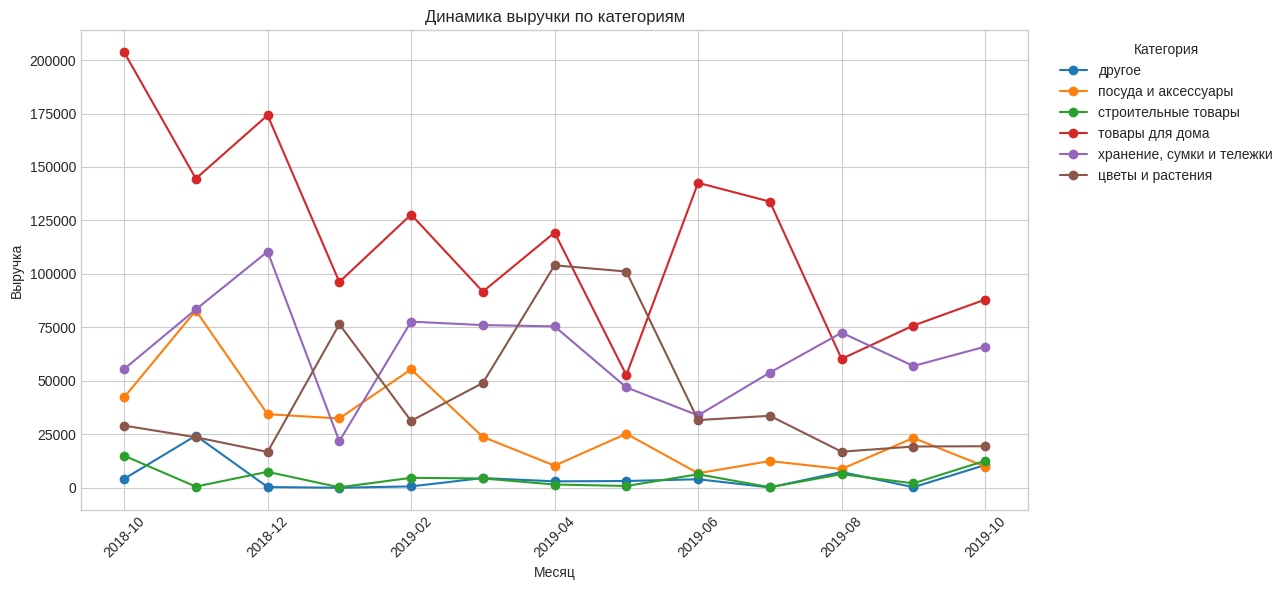

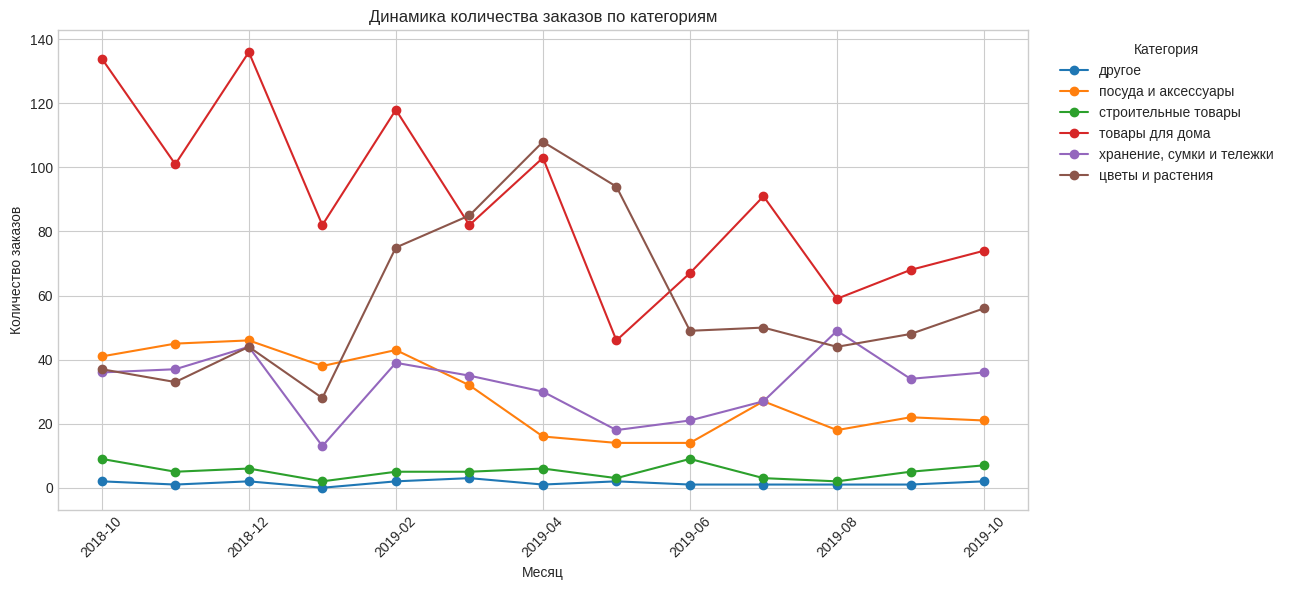

In [11]:
monthly_summary = build_monthly_summary(transactions)
display(monthly_summary.head(12))

line_plot(monthly_summary, 'revenue', 'Динамика выручки по категориям', 'Выручка')
line_plot(monthly_summary, 'orders', 'Динамика количества заказов по категориям', 'Количество заказов')

,month,revenue,orders,avg_order_value
0,2018-10,"349,651.00",259,"1,350.00"
1,2018-11,"359,348.00",222,"1,618.68"
2,2018-12,"343,560.00",278,"1,235.83"
3,2019-01,"227,039.00",163,"1,392.88"
4,2019-02,"297,358.00",282,"1,054.46"
5,2019-03,"249,429.00",242,"1,030.70"
6,2019-04,"313,667.00",264,"1,188.13"
7,2019-05,"229,976.00",177,"1,299.30"
8,2019-06,"225,116.00",161,"1,398.24"
9,2019-07,"234,190.00",199,"1,176.83"


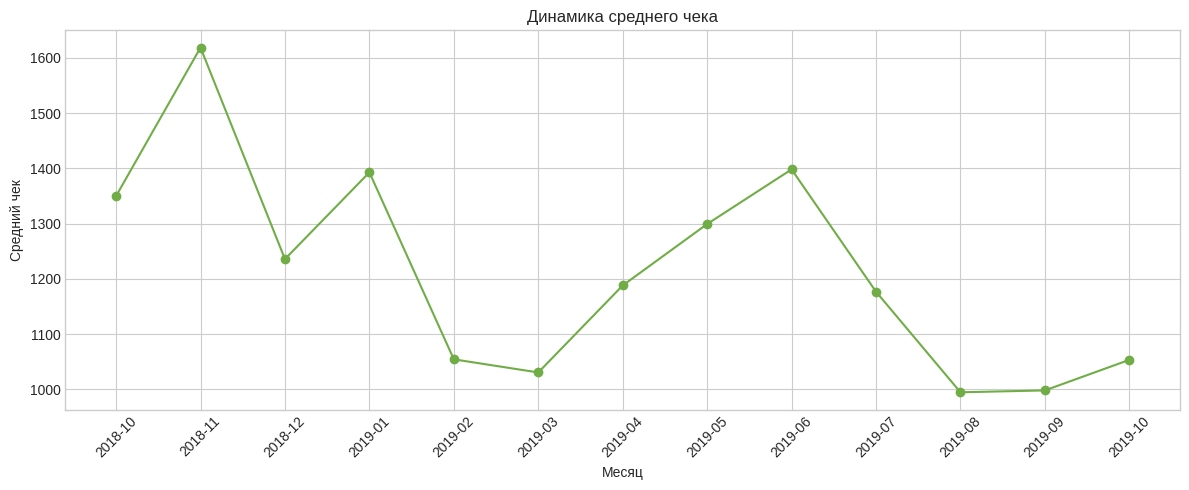

In [12]:
monthly_total = (
    monthly_summary.groupby('month', as_index=False)
    .agg(revenue=('revenue', 'sum'), orders=('orders', 'sum'))
)
monthly_total['avg_order_value'] = monthly_total['revenue'] / monthly_total['orders']

display(monthly_total.round({'revenue': 2, 'avg_order_value': 2}))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_total['month'], monthly_total['avg_order_value'], marker='o', color='#70AD47')
ax.set_title('Динамика среднего чека')
ax.set_xlabel('Месяц')
ax.set_ylabel('Средний чек')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Промежуточный вывод:** в динамике видны сезонные пики и просадки. Для цветов и растений ожидаемо важен весенний период, а товары для дома остаются базовой категорией для регулярных коммуникаций.

## 5. RFM-сегментация покупателей

RFM-метрики:

- `recency` — сколько дней прошло с последней покупки;
- `frequency` — сколько заказов сделал покупатель;
- `monetary_value` — средний чек покупателя.

Так как большинство покупателей совершили один заказ, `frequency` разделён на две группы: один заказ и больше одного заказа.

,customer_id,last_order_date,frequency,total_revenue,recency,monetary_value,r_score,f_score,m_score,rfm_code,customer_segment
175,126dac4d-6486-49ed-a1be-9fd55a38a9de,2019-08-28 02:00:00,2,"9,148.00",64,"4,574.00",3,2,3,323,лояльные
1127,7abce1cc-bc8c-4362-b61a-0cbb4822ed29,2019-10-03 13:00:00,2,"7,950.00",28,"3,975.00",3,2,3,323,лояльные
2335,facadcf2-2c13-4d8f-baa3-567821546534,2019-07-19 08:00:00,2,"7,049.00",104,"3,524.50",3,2,3,323,лояльные
769,540072bd-cc85-43b5-a6d6-0a8720499e65,2019-08-18 10:00:00,2,"6,898.00",74,"3,449.00",3,2,3,323,лояльные
1340,922f7c8c-9241-4d9a-a37e-1f7dd1b03568,2019-09-19 13:00:00,2,"3,674.00",42,"1,837.00",3,2,3,323,лояльные


,customer_segment,revenue,orders,items,customers,avg_recency_days,avg_frequency,avg_customer_check,avg_order_value,orders_per_customer
0,лояльные,"100,344.00",79,143,30,48.80,2.63,"1,296.87","1,270.18",2.63
1,новые,"606,683.00",583,1798,567,54.90,1.03,"1,066.02","1,040.62",1.03
2,потенциальные,"851,733.00",674,4103,599,164.70,1.13,"1,244.19","1,263.70",1.13
3,спящие,"1,826,847.00",1406,6332,1187,299.10,1.18,"1,295.19","1,299.32",1.18


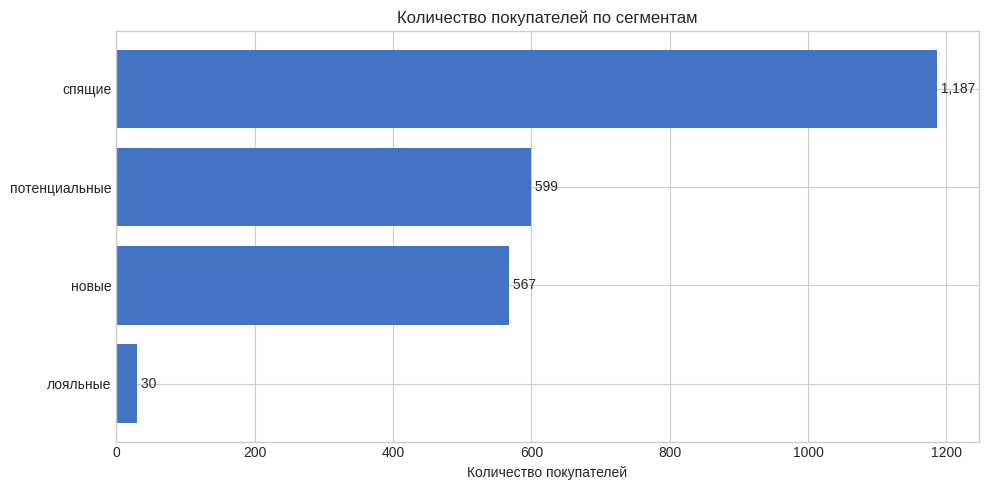

In [13]:
rfm = build_rfm_table(transactions)
segmented_transactions = attach_segments(transactions, rfm)
segment_summary = build_segment_summary(segmented_transactions, rfm)
segment_category_summary = build_segment_category_summary(segmented_transactions)

display(rfm.head())
display(segment_summary)

barh_table_plot(
    segment_summary,
    x='customers',
    y='customer_segment',
    title='Количество покупателей по сегментам',
    xlabel='Количество покупателей',
)

**Промежуточный вывод:** самая крупная группа — спящие клиенты. Лояльных покупателей мало, но они делают больше заказов на клиента. Новые клиенты имеют самый низкий средний чек, поэтому для них особенно важны повторные покупки и механики роста корзины.

## 6. Проверка статистических гипотез

Проверим различия между сегментами по среднему чеку покупателя и частоте заказов.

- `H0`: между двумя сегментами нет статистически значимой разницы.
- `H1`: между двумя сегментами есть статистически значимая разница.

Используется непараметрический тест Манна-Уитни и поправка Холма для множественных сравнений.

In [14]:
statistical_tests = pd.concat(
    [
        compare_segments(rfm, 'monetary_value'),
        compare_segments(rfm, 'frequency'),
    ],
    ignore_index=True,
)

display(statistical_tests.round({'statistic': 2, 'p_value': 6, 'adjusted_p_value': 6}))

,metric,segment_a,segment_b,statistic,p_value,adjusted_p_value,reject_h0,conclusion
0,monetary_value,новые,спящие,"300,176.50",0.00,0.00,True,есть статистически значимая разница
1,monetary_value,лояльные,новые,"10,909.00",0.01,0.05,True,есть статистически значимая разница
2,monetary_value,лояльные,потенциальные,"11,141.00",0.03,0.11,False,статистически значимой разницы не обнаружено
3,monetary_value,потенциальные,спящие,"334,909.50",0.05,0.14,False,статистически значимой разницы не обнаружено
4,monetary_value,лояльные,спящие,"20,879.50",0.11,0.21,False,статистически значимой разницы не обнаружено
5,monetary_value,новые,потенциальные,"161,054.50",0.13,0.21,False,статистически значимой разницы не обнаружено
6,frequency,лояльные,спящие,"34,788.00",0.00,0.00,True,есть статистически значимая разница
7,frequency,лояльные,новые,"16,806.00",0.00,0.00,True,есть статистически значимая разница
8,frequency,лояльные,потенциальные,"17,096.50",0.00,0.00,True,есть статистически значимая разница
9,frequency,новые,потенциальные,"158,658.50",0.00,0.00,True,есть статистически значимая разница


**Промежуточный вывод:** по частоте заказов сегменты различаются сильнее, чем по среднему чеку. Это ожидаемо: сама RFM-сегментация учитывает частоту, а средний чек у части сегментов близок.

## 7. Товарные предпочтения сегментов

,customer_segment,category,revenue,orders,items
0,лояльные,"хранение, сумки и тележки","48,343.00",26,27
1,лояльные,товары для дома,"31,770.00",23,28
2,лояльные,цветы и растения,"16,351.00",25,81
3,лояльные,посуда и аксессуары,"2,801.00",5,5
4,лояльные,строительные товары,"1,079.00",2,2
5,новые,товары для дома,"273,589.00",231,633
6,новые,"хранение, сумки и тележки","184,681.00",112,119
7,новые,цветы и растения,"62,357.00",150,350
8,новые,посуда и аксессуары,"47,725.00",72,391
9,новые,строительные товары,"20,109.00",14,301


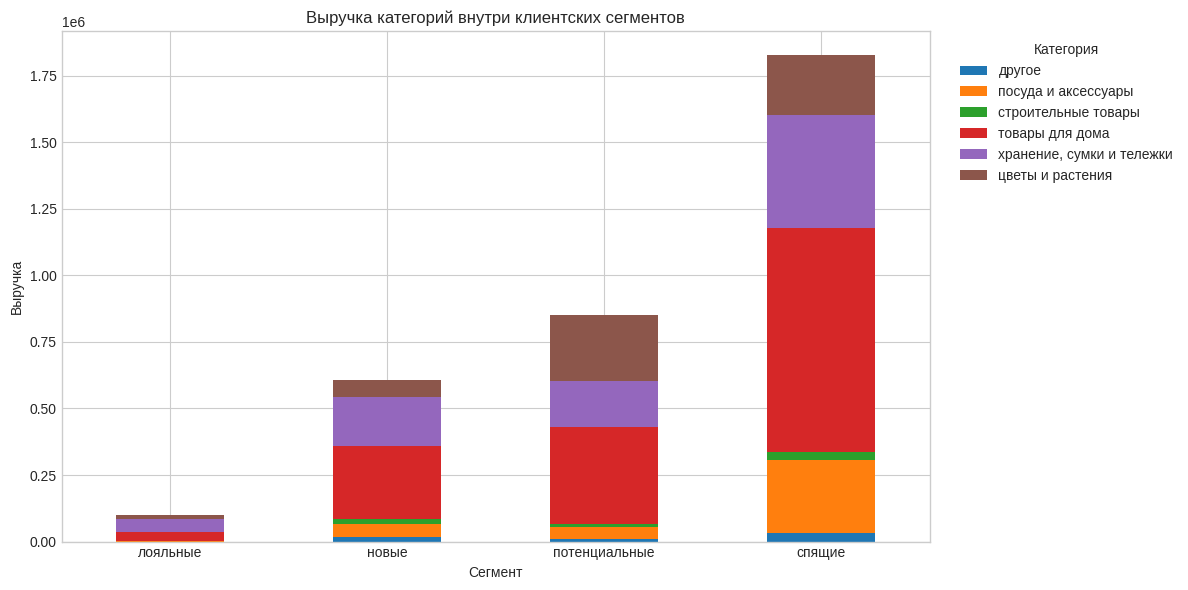

In [15]:
display(segment_category_summary)

pivot_segment_category = segment_category_summary.pivot_table(
    index='customer_segment',
    columns='category',
    values='revenue',
    aggfunc='sum',
    fill_value=0,
)
pivot_segment_category = pivot_segment_category.reindex(SEGMENT_ORDER)

ax = pivot_segment_category.plot(kind='bar', stacked=True, figsize=(12, 6))
ax.set_title('Выручка категорий внутри клиентских сегментов')
ax.set_xlabel('Сегмент')
ax.set_ylabel('Выручка')
ax.legend(title='Категория', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Итоговые рекомендации

**Лояльные клиенты**  
Развивать программу лояльности, персональные предложения и ранний доступ к сезонным подборкам. Для этой группы важно удержание: бонусы за повторные покупки, персональные скидки и рекомендации на основе прошлых покупок.

**Новые клиенты**  
Стимулировать вторую покупку: приветственная цепочка, скидка на следующий заказ, подборки товаров для дома, посуды и растений. Для роста среднего чека стоит тестировать комплекты и пороговые скидки.

**Потенциальные клиенты**  
Поддерживать контакт между сезонными всплесками. Весной делать акцент на цветах и растениях, в остальное время продвигать всесезонные товары для дома.

**Спящие клиенты**  
Запускать реактивационные кампании: персональная скидка, бонус за возвращение, короткий опрос о причинах неактивности. Так как сегмент большой, кампании лучше запускать через A/B-тесты и контролировать экономику скидок.

**Что улучшить дальше**

- Уточнить правила категоризации для товаров из группы `другое`.
- Добавить проверку маржинальности, если появятся себестоимость и скидки.
- Считать когортное удержание, чтобы отделить сезонность от качества повторных покупок.
- Проверять маркетинговые гипотезы через A/B-тесты, а не только через исторические данные.

## 9. Сохранение итоговых таблиц

In [16]:
result_tables = {
    'cleaning_report': cleaning_report_df,
    'category_summary': category_summary,
    'monthly_summary': monthly_summary,
    'rfm_segments': rfm,
    'segment_summary': segment_summary,
    'segment_category_summary': segment_category_summary,
    'statistical_tests': statistical_tests,
}

for table_name, table in result_tables.items():
    table.to_csv(OUTPUT_DIR / f'{table_name}.csv', index=False)

transactions.to_csv(OUTPUT_DIR / 'cleaned_transactions.csv', index=False)

print(f'Итоговые таблицы сохранены в: {OUTPUT_DIR.resolve()}')

Итоговые таблицы сохранены в: /home/kate/Documents/1/outputs/notebook_analysis
